# Mass Spectrum 분석

**Mass Spectrum**은 특정 시점(RT)에서 검출된 **모든 이온의 m/z 분포**입니다. TIC가 "시간에 따른 전체 강도 변화"를 보여준다면, mass spectrum은 "한 순간에 어떤 이온들이 존재하는지"를 보여줍니다.

질량분석에서 mass spectrum을 확인하는 이유는 다음과 같습니다:
- **화합물 존재 확인**: target m/z 위치에 실제 피크가 있는지 직접 확인
- **간섭 이온 파악**: target 근처에 다른 이온이 있으면 XIC에 간섭이 발생할 수 있음
- **mass accuracy 평가**: 이론적 m/z와 실측 m/z의 차이(ppm)로 데이터 품질 확인
- **시점별 비교**: 시료 주입 시점 vs 비주입 시점의 스펙트럼 차이로 진짜 신호 구분

이 노트북에서는:
1. `get_spectrum_at_rt()` 함수로 특정 시점의 전체 mass spectrum 추출
2. 화합물별 m/z 영역 확대 (Compound Zoom, +/-5 Da)
3. 서로 다른 RT 시점의 스펙트럼 비교

In [1]:
!pip install -q pyopenms scipy matplotlib numpy pandas openpyxl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks
from scipy import integrate
import pyopenms as oms
import openpyxl, os, warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

### 데이터 로드 및 전처리

mzML 파일을 로드하고, TIC/XIC 추출 함수를 정의한 뒤, 화합물 목록을 엑셀에서 가져옵니다. 이 셀은 이전 노트북에서 정의한 변수와 함수를 복원하는 역할을 합니다.

- `load_mzml()`: pyopenms로 mzML 파싱 -> `MSExperiment` 객체
- `extract_tic()` / `extract_xic()`: TIC, XIC 계산 함수
- `target_compounds`: 분석 대상 7종 화합물의 m/z 및 adduct 정보

In [2]:
# === 데이터 로드 ===
DATA_DIR = 'echo-tof-colab/data'
MZML_DIR = f'{DATA_DIR}/mzml'
TOFMS_FILE = f'{MZML_DIR}/20260330_TOFMS.mzML'
MRMHR_FILE = f'{MZML_DIR}/20260330_MRMHR_Q1Q3_Final.mzML'
EXCEL_FILE = f'{DATA_DIR}/Explosives_EchoMS_20260331.xlsx'

def load_mzml(filepath):
    """mzML 파일을 로드하여 MSExperiment 객체 반환"""
    exp = oms.MSExperiment()
    oms.MzMLFile().load(filepath, exp)
    print(f'로드 완료: {os.path.basename(filepath)} ({exp.getNrSpectra()} spectra)')
    return exp

exp_tof = load_mzml(TOFMS_FILE)

def extract_tic(exp, ms_level=1):
    """TIC 추출"""
    rt_list, tic_list = [], []
    for spec in exp:
        if spec.getMSLevel() == ms_level:
            rt_list.append(spec.getRT() / 60.0)
            mz, intensity = spec.get_peaks()
            tic_list.append(np.sum(intensity))
    return np.array(rt_list), np.array(tic_list)

rt_tof, tic_tof = extract_tic(exp_tof)

def extract_xic(exp, target_mz, tolerance_ppm=20.0, ms_level=1):
    """XIC 추출: target_mz ± tolerance 범위의 intensity 합"""
    rt_list, int_list = [], []
    tol = target_mz * tolerance_ppm * 1e-6
    for spec in exp:
        if spec.getMSLevel() == ms_level:
            rt_list.append(spec.getRT() / 60.0)
            mz, ints = spec.get_peaks()
            mask = (mz >= target_mz - tol) & (mz <= target_mz + tol)
            int_list.append(float(ints[mask].sum()) if mask.any() else 0.0)
    return np.array(rt_list), np.array(int_list)

# 화합물 스킴 로드
wb = openpyxl.load_workbook(EXCEL_FILE, data_only=True)
ws_std = wb['STD list']
compounds = []
for row in ws_std.iter_rows(min_row=2, max_row=16, values_only=True):
    if row[0] and row[1]:
        compounds.append({'name': str(row[2] or row[1]), 'full_name': str(row[1]), 'mz': None})

# XIC 추출
target_compounds = {
    'TNT': {'mz': 226.009, 'adduct': '[M-H]-'},
    'RDX': {'mz': 281.048, 'adduct': '[M+CH3COO]-'},
    'HMX': {'mz': 355.0592, 'adduct': '[M+CH3COO]-'},
    '2,4-DNT': {'mz': 181.0124, 'adduct': '[M-H]-'},
    'Tetryl': {'mz': 241.0204, 'adduct': '[M-NO2]-'},
    '4-Am-DNT': {'mz': 196.0358, 'adduct': '[M-H]-'},
    '2,6-DNT': {'mz': 182.018, 'adduct': '[M]-'},
}

xic_data = {}
for name, info in target_compounds.items():
    rt, intensity = extract_xic(exp_tof, info['mz'])
    xic_data[name] = {'rt': rt, 'intensity': intensity, 'mz': info['mz']}

detected = {k: v for k, v in xic_data.items() if v['intensity'].max() > 0}
print(f'검출된 화합물: {len(detected)}/{len(target_compounds)}')

Loaded: 20260330_TOFMS.mzML (495 spectra)
Detected compounds: 7/7



## 특정 시점의 Mass Spectrum 추출

`get_spectrum_at_rt()` 함수는 지정한 Retention Time에 **가장 가까운 스캔**을 찾아 전체 mass spectrum을 반환합니다. TOF 데이터는 일정 주기(~0.228초 간격)로 스캔을 반복하므로, 원하는 시점에 정확히 맞는 스캔이 없을 수 있습니다. 따라서 시간 차이가 최소인 스캔을 선택합니다.

- **입력**: 목표 RT (분), MS level (1=MS1 full scan)
- **출력**: m/z 배열, intensity 배열, 실제 스캔 RT
- 이 함수를 사용하면 TIC 피크 시점, 특정 echo drop 시점 등 원하는 순간의 이온 구성을 확인할 수 있습니다

In [3]:
def get_spectrum_at_rt(exp, target_rt_min, ms_level=1):
    """특정 RT에 가장 가까운 스캔의 mass spectrum 반환"""
    target_rt_sec = target_rt_min * 60.0
    best_spec = None
    best_diff = float('inf')
    for spec in exp:
        if spec.getMSLevel() != ms_level:
            continue
        diff = abs(spec.getRT() - target_rt_sec)
        if diff < best_diff:
            best_diff = diff
            best_spec = spec
    if best_spec is None:
        return None, None, None
    mz, intensity = best_spec.get_peaks()
    return mz, intensity, best_spec.getRT() / 60.0

print('특정 시점 스펙트럼 추출 함수 정의 완료.')

Spectrum extraction function defined.



### TIC 피크 시점의 전체 Mass Spectrum

TIC가 최대인 시점은 가장 많은 이온이 검출된 순간으로, echo drop이 주입된 직후에 해당합니다. 이 시점의 mass spectrum을 보면 **시료에 포함된 모든 화합물의 m/z를 한 눈에 확인**할 수 있습니다.

아래 그래프에서는:
- **남색 막대**: 실제 검출된 모든 이온 (m/z vs intensity)
- **색상 점선**: 각 타겟 화합물의 이론적 m/z 위치
- **레이블**: 상위 15개 피크의 m/z 값 -- 타겟 화합물 외에도 용매 클러스터, adduct 이온 등이 보일 수 있습니다
- 타겟 m/z 위치에 실제 피크가 겹치면 해당 화합물이 존재하는 것입니다

TIC Peak RT: 1.437 min -> Scan RT: 1.437 min
Ions: 10895
m/z range: 100.0 ~ 499.3


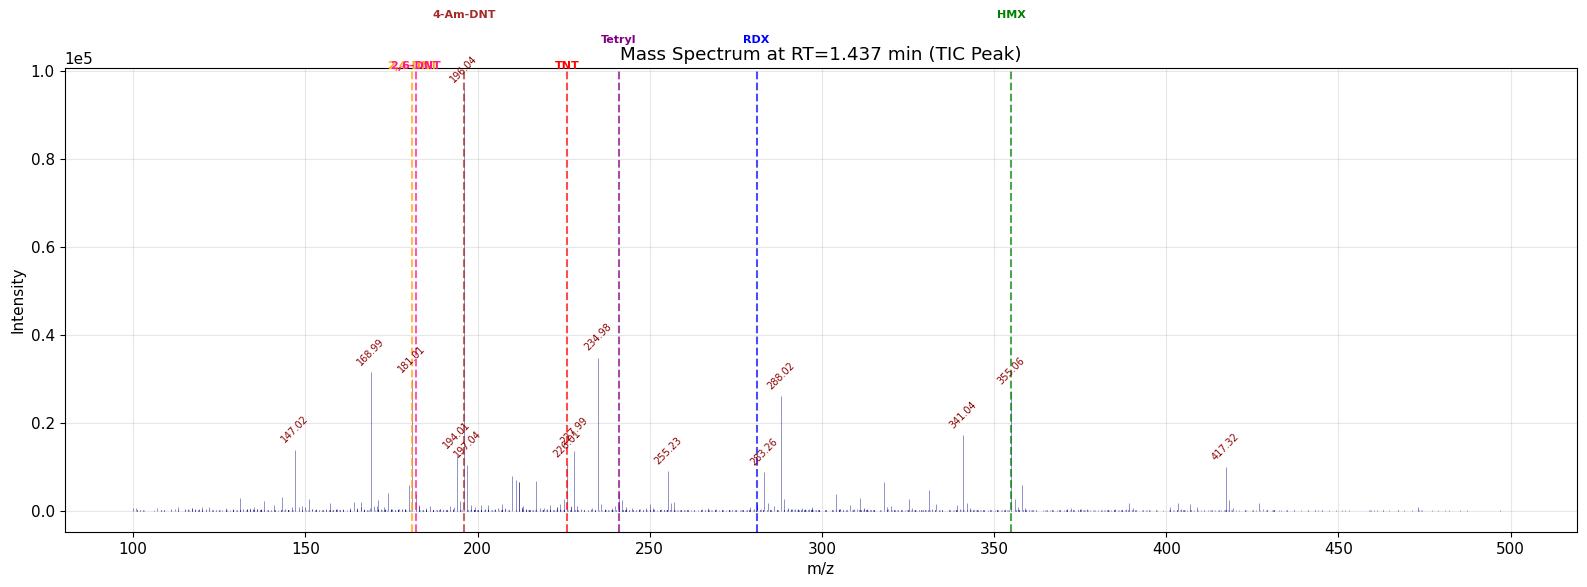

In [4]:
# TIC 피크 시점 - 전체 mass spectrum (화합물 위치 표시)
peak_rt = rt_tof[np.argmax(tic_tof)]
mz_spec, int_spec, actual_rt = get_spectrum_at_rt(exp_tof, peak_rt)

print(f'TIC Peak RT: {peak_rt:.3f} min -> Scan RT: {actual_rt:.3f} min')
print(f'이온 수: {len(mz_spec)}')
print(f'm/z 범위: {mz_spec.min():.1f} ~ {mz_spec.max():.1f}')

fig, ax = plt.subplots(figsize=(16, 6))
ax.vlines(mz_spec, 0, int_spec, colors='navy', linewidth=0.5, alpha=0.6)

# Mark all target compounds
ymax = int_spec.max()
colors_list = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'deeppink']
for idx, (name, info) in enumerate(target_compounds.items()):
    c = colors_list[idx % len(colors_list)]
    ax.axvline(info['mz'], color=c, linestyle='--', alpha=0.7, linewidth=1.5)
    ax.text(info['mz'], ymax * (1.05 + 0.06 * (idx % 3)), name,
           ha='center', fontsize=8, color=c, fontweight='bold')

# Top 15 peak labels
top15 = np.argsort(int_spec)[-15:]
for i in top15:
    if int_spec[i] > ymax * 0.05:
        ax.annotate(f'{mz_spec[i]:.2f}', (mz_spec[i], int_spec[i]),
                   textcoords='offset points', xytext=(0, 5),
                   fontsize=7, ha='center', color='darkred', rotation=45)

ax.set_xlabel('m/z')
ax.set_ylabel('Intensity')
ax.set_title(f'Mass Spectrum at RT={actual_rt:.3f} min (TIC Peak)')
ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 화합물별 m/z 확대 보기 (Compound Zoom, +/-5 Da)

전체 mass spectrum에서는 수백~수천 개의 이온이 m/z 50~1000 범위에 분포하므로, 개별 화합물의 피크를 세밀하게 보기 어렵습니다. 각 화합물의 target m/z를 중심으로 **+/-5 Da 범위**를 확대하면 실제 검출 여부를 명확히 확인할 수 있습니다.

- **빨간 점선**: 이론적 target m/z 위치 (adduct 고려한 값)
- **남색 막대**: 실제 검출된 이온들
- monoisotopic peak (M)과 동위원소 피크 (M+1, M+2)가 함께 보여야 정상적인 검출
- target m/z와 가장 가까운 피크의 m/z 차이를 보면 **mass accuracy** (ppm 오차)를 평가할 수 있습니다
- 피크가 전혀 없으면 해당 화합물은 이 시점에서 검출되지 않은 것입니다

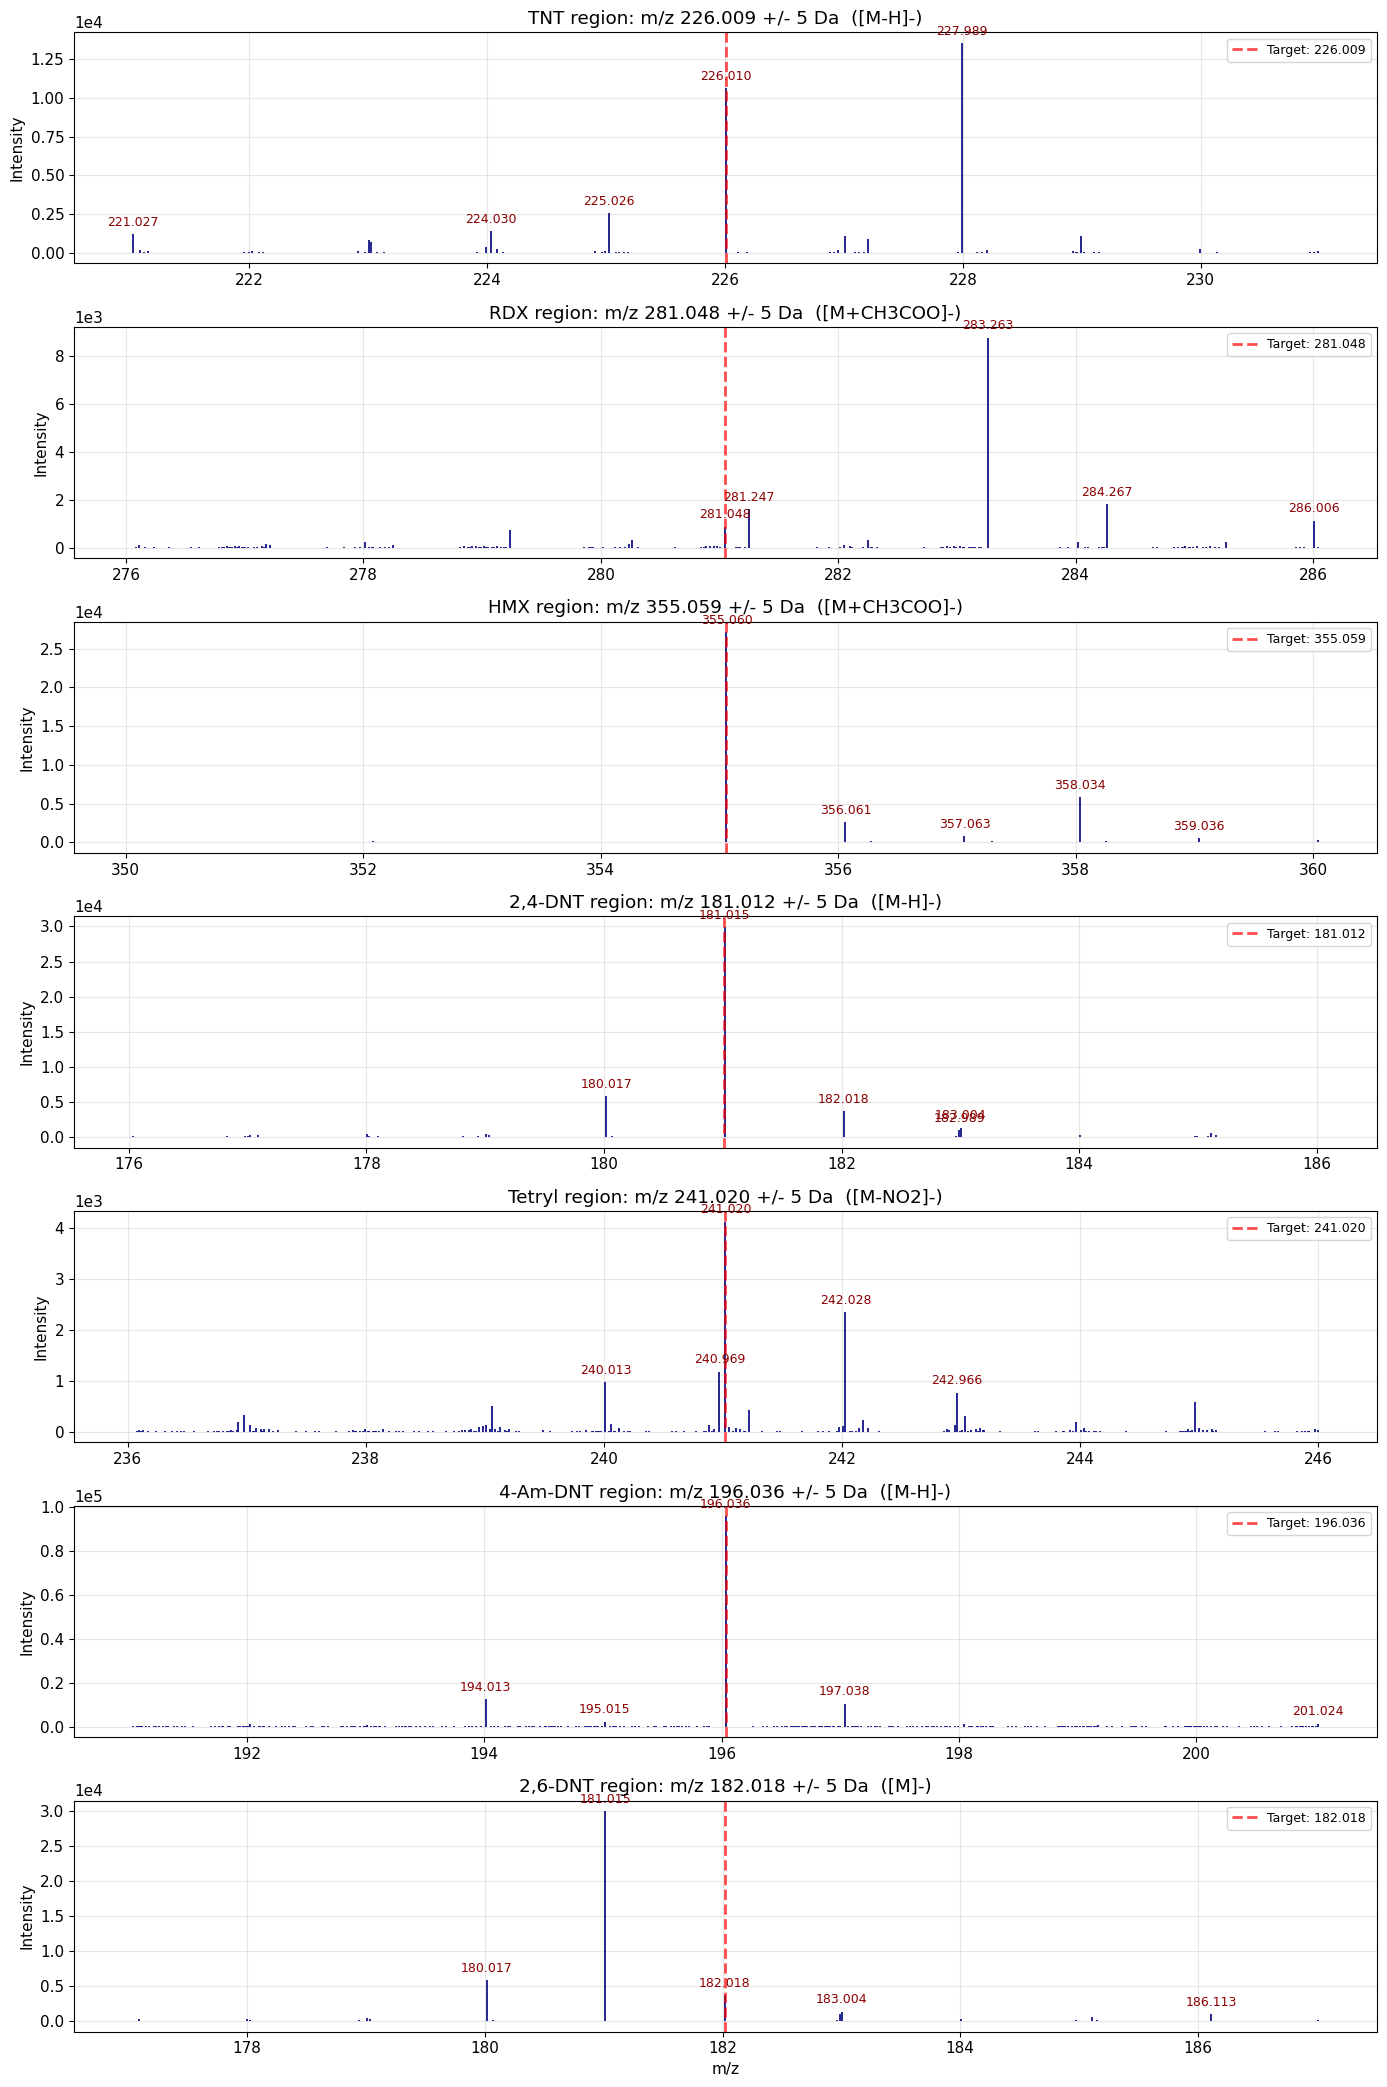

In [5]:
# 화합물별 m/z 확대 (+/- 5 Da)
n_comp = len(target_compounds)
fig, axes = plt.subplots(n_comp, 1, figsize=(14, 3 * n_comp))

for ax, (name, info) in zip(axes, target_compounds.items()):
    cmz = info['mz']
    window = 5.0
    mask = (mz_spec >= cmz - window) & (mz_spec <= cmz + window)
    mz_local = mz_spec[mask]
    int_local = int_spec[mask]
    
    if len(mz_local) > 0:
        ax.vlines(mz_local, 0, int_local, colors='navy', linewidth=1.2)
        ax.axvline(cmz, color='red', linestyle='--', alpha=0.7, linewidth=2,
                  label=f'Target: {cmz:.3f}')
        
        # Top 5 peak labels
        if len(int_local) > 0:
            top5 = np.argsort(int_local)[-5:]
            for i in top5:
                ax.annotate(f'{mz_local[i]:.3f}',
                           (mz_local[i], int_local[i]),
                           textcoords='offset points', xytext=(0, 6),
                           fontsize=9, ha='center', color='darkred')
    
    ax.set_title(f'{name} region: m/z {cmz:.3f} +/- {window:.0f} Da  ({info["adduct"]})')
    ax.set_ylabel('Intensity')
    ax.legend(fontsize=9)
    ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('m/z')
plt.tight_layout()
plt.show()

### 시점별 Mass Spectrum 비교

**목적**: 특정 m/z의 피크가 echo drop 시점에서만 나타나는지, 항상 나타나는지 구분합니다.

- **drop 시점에만 나타나는 피크** → 시료 화합물
- **모든 시점에서 나타나는 피크** → background ion (용매 클러스터, 노이즈)

4개 시점을 비교합니다. **빨간 영역**이 target 화합물 위치이고,
drop이 없는 시점(25%, 75%)에서는 이 영역의 피크가 사라져야 합니다.

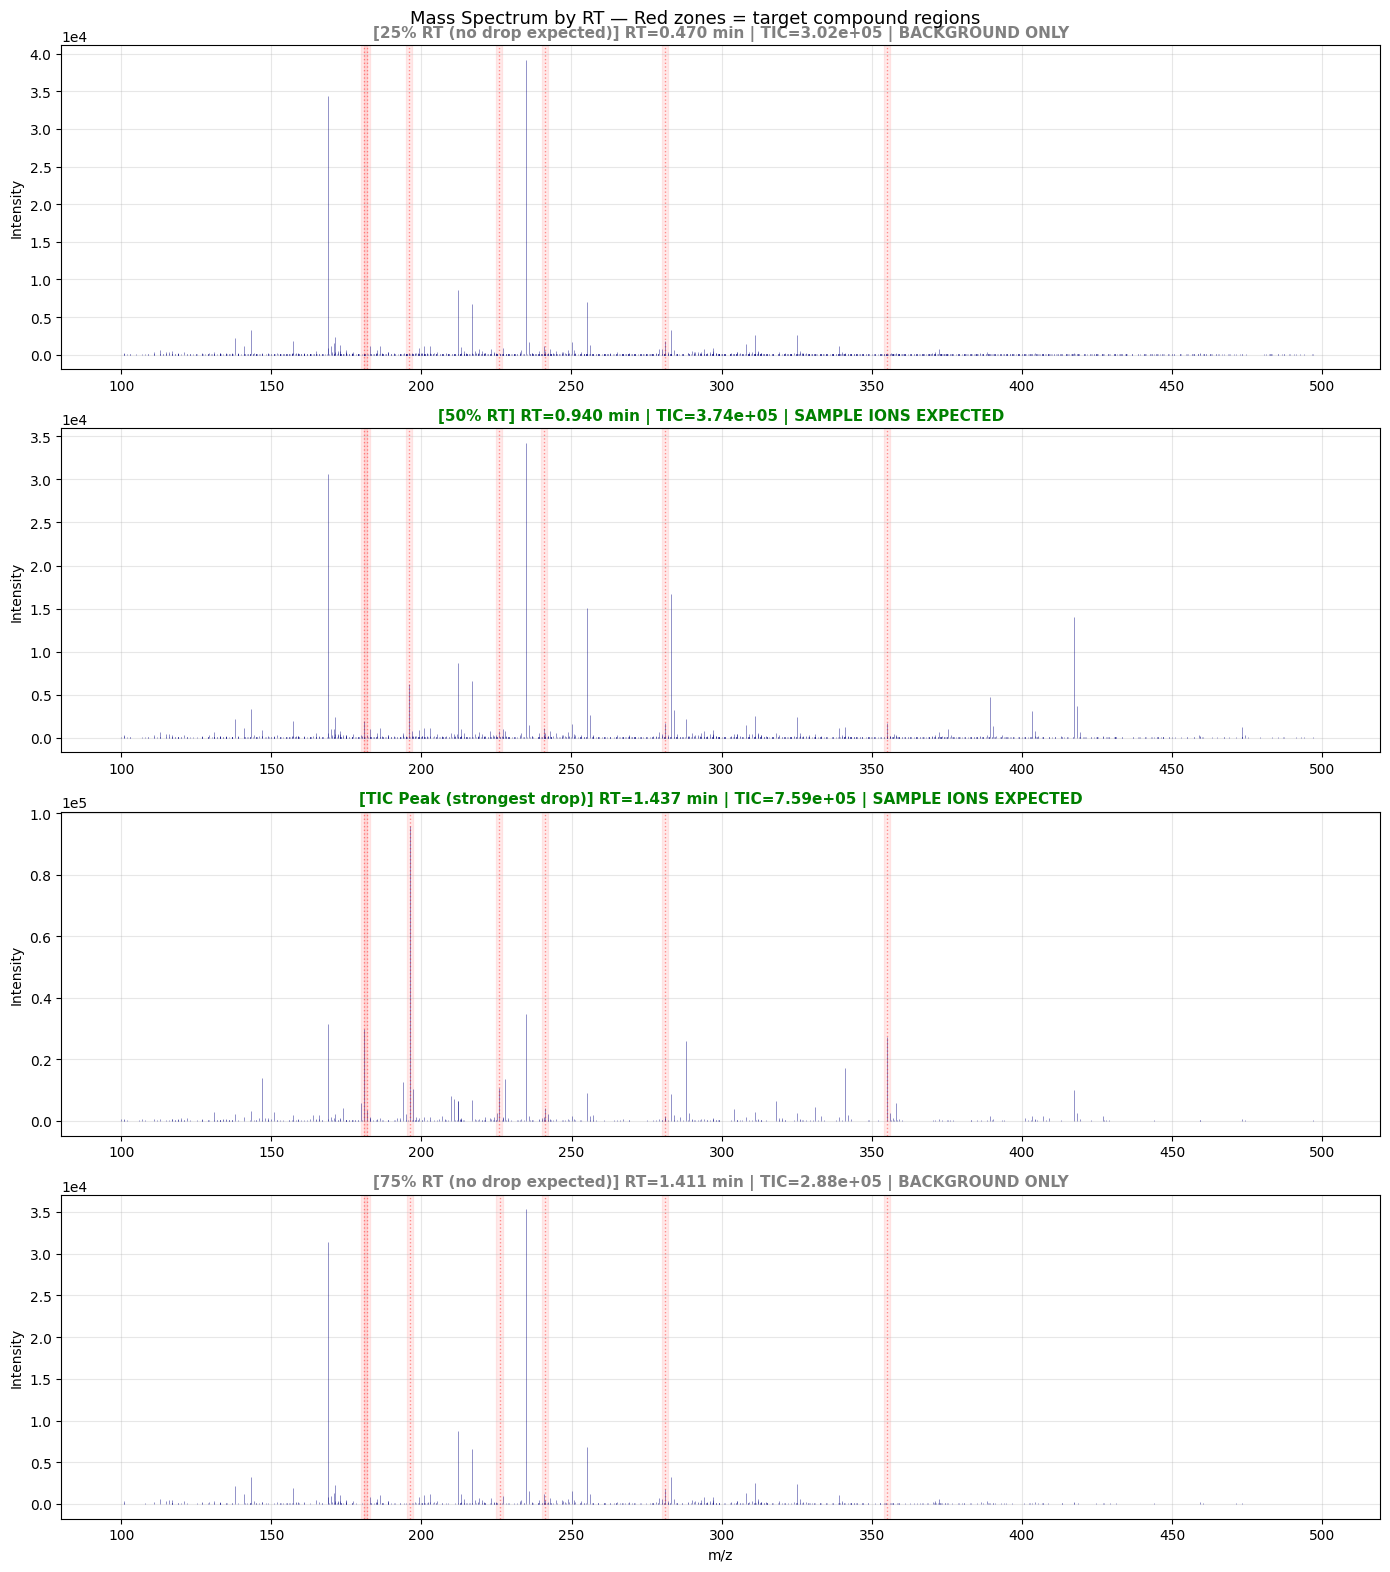

In [3]:
# 시점별 mass spectrum 비교 (개선: target 영역 강조)
rt_points = [
    rt_tof[len(rt_tof)//4],
    rt_tof[len(rt_tof)//2],
    rt_tof[np.argmax(tic_tof)],
    rt_tof[3*len(rt_tof)//4],
]
labels = ['25% RT (no drop expected)', '50% RT', 'TIC Peak (strongest drop)', '75% RT (no drop expected)']
is_drop = [False, True, True, False]  # drop이 있을 것으로 예상되는 시점

fig, axes = plt.subplots(len(rt_points), 1, figsize=(14, 4 * len(rt_points)))

for ax, target_rt, label, drop_expected in zip(axes, rt_points, labels, is_drop):
    mz_s, int_s, act_rt = get_spectrum_at_rt(exp_tof, target_rt)
    
    if mz_s is not None and len(mz_s) > 0:
        ax.vlines(mz_s, 0, int_s, colors='navy', linewidth=0.5, alpha=0.6)
        ymax = int_s.max() if int_s.max() > 0 else 1
        
        # Target 화합물 위치 강조 (빨간 영역)
        for name, info in target_compounds.items():
            tmz = info['mz']
            # ±1 Da 영역을 하이라이트
            ax.axvspan(tmz - 1, tmz + 1, alpha=0.08, color='red')
            ax.axvline(tmz, color='red', linestyle=':', alpha=0.4, linewidth=1)
        
        tic_val = np.sum(int_s)
        status = 'SAMPLE IONS EXPECTED' if drop_expected else 'BACKGROUND ONLY'
        color = 'green' if drop_expected else 'gray'
        ax.set_title(f'[{label}] RT={act_rt:.3f} min | TIC={tic_val:.2e} | {status}',
                    fontsize=11, color=color, fontweight='bold')
    else:
        ax.set_title(f'[{label}] RT={target_rt:.3f} min - No data')
    
    ax.set_ylabel('Intensity')
    ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('m/z')
plt.suptitle('Mass Spectrum by RT — Red zones = target compound regions', fontsize=13)
plt.tight_layout()
plt.show()


---

⬅️ **Prev:** [Setup / TIC / Baseline](01%20Setup%20TIC%20Baseline.ipynb) | **Next:** [XIC Extraction](03%20XIC%20Extraction.ipynb) ➡️